In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# ------------------------------------------------------------
# Загрузка данных из CSV-файла с обработкой нестандартного формата
# ------------------------------------------------------------
# В исходных данных иногда присутствует дополнительный столбец 'ls_method'
# (например, 'clustering_sa') после param_strategy, а param_verbose опущен.
# Чтобы корректно всё прочитать, зададим имена столбцов с запасом.c
column_names = [
    'instance', 'optimum', 'found', 'gap', 'status', 'best_perm', 'time_sec',
    'param_pop_size', 'param_gens', 'param_cross_rate', 'param_mut_rate',
    'param_tourn_size', 'param_elitism', 'param_use_local_search',
    'param_ls_freq', 'param_strategy', 'param_verbose', 'ls_method'
]

cwd = os.getcwd()
csv_path = os.path.join(cwd, 'configs', 'ea_results.csv')

df = pd.read_csv(csv_path, names=column_names, skiprows=1,dtype={'param_verbose': str}, na_values=[''])

In [10]:
# Если в строке 18 полей, ls_method получает 'clustering_sa',
# а param_verbose становится NaN. Заполним его предполагаемым True.
df['param_verbose'] = df['param_verbose'].fillna('True').astype(str)
# Для строк без clustering_sa в ls_method останется NaN – заменим на 'none'
df['ls_method'] = df['ls_method'].fillna('none')

# Преобразуем типы
df['gap'] = pd.to_numeric(df['gap'], errors='coerce')
df['time_sec'] = pd.to_numeric(df['time_sec'], errors='coerce')
df['optimum'] = pd.to_numeric(df['optimum'], errors='coerce')
df['found'] = pd.to_numeric(df['found'], errors='coerce')

# Извлекаем размер задачи из имени экземпляра (например, chr20a -> 20)
df['size'] = df['instance'].str.extract(r'(\d+)').astype(int)

# Для удобства объединим стратегию и метод локального поиска в одну категорию
df['strategy_full'] = df.apply(
    lambda row: f"{row['param_strategy']}_{row['ls_method']}"
    if row['ls_method'] != 'none' else row['param_strategy'],
    axis=1
)

df['fitness_evals'] = df['param_pop_size'] * df['param_gens']
# Показатель эффективности: чем меньше gap и время, тем лучше
epsilon = 1e-6
df['efficiency'] = 1.0 / (df['gap'] * df['time_sec'] + epsilon)
# Логарифмическая версия (чтобы не было экстремальных значений)
df['log_efficiency'] = np.log10(df['efficiency'] + 1)

# Убедимся, что числовые колонки действительно числа
for col in ['param_pop_size', 'param_gens', 'param_cross_rate', 'param_mut_rate',
            'param_tourn_size', 'param_ls_freq']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Элитизм – обычно булево значение, переведём в int
df['param_elitism'] = df['param_elitism'].astype(str).str.lower().map({'true':1,'false':0}).fillna(0).astype(int)

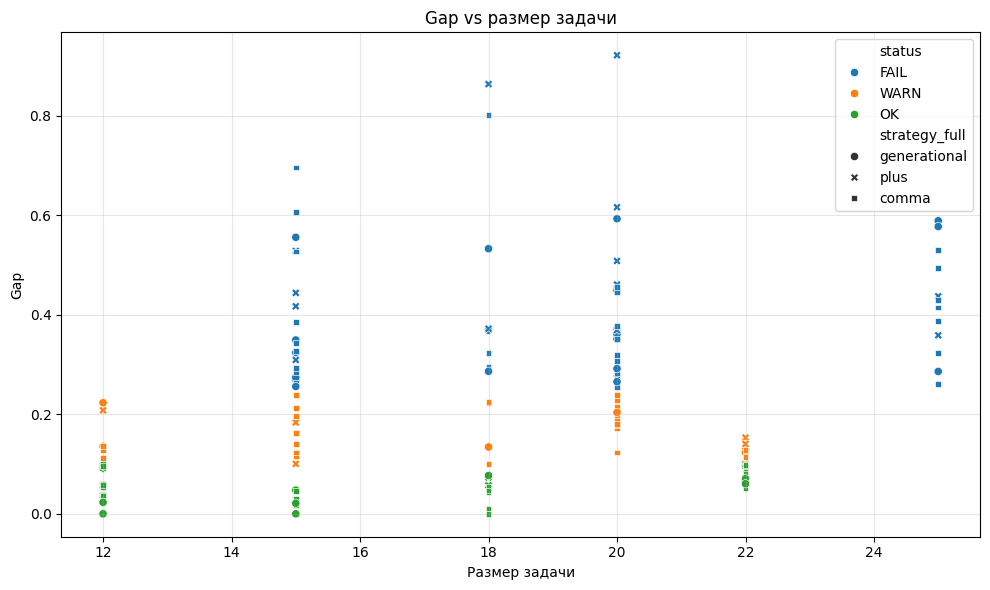

In [ ]:
# ------------------------------------------------------------
# Зависимость gap от размера задачи
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size', y='gap', hue='status', style='strategy_full')
plt.title('Gap vs размер задачи')
plt.xlabel('Размер задачи')
plt.ylabel('Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


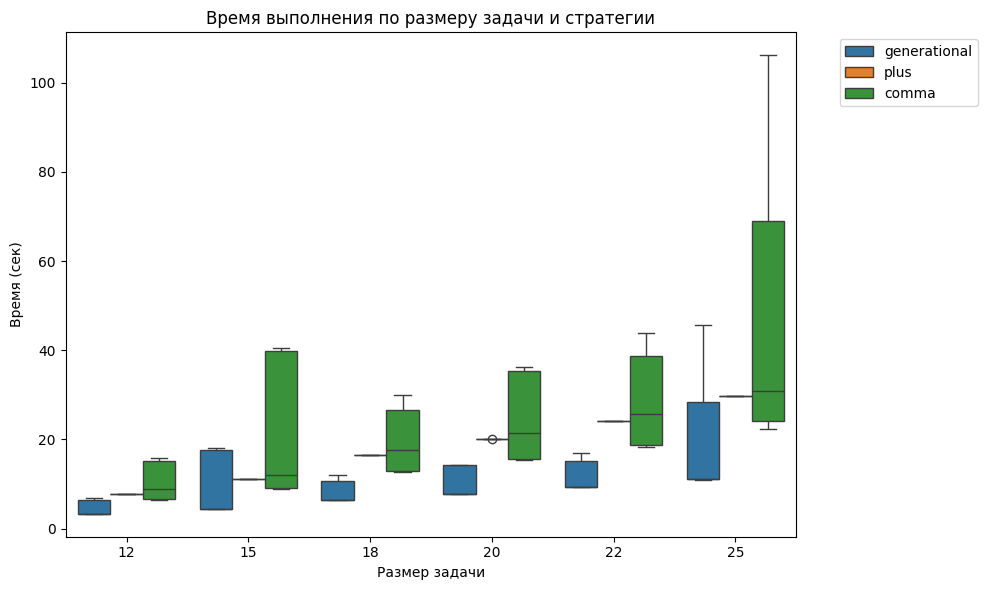

In [7]:
# ------------------------------------------------------------
# Время выполнения в зависимости от размера задачи и стратегии
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='size', y='time_sec', hue='strategy_full')
plt.title('Время выполнения по размеру задачи и стратегии')
plt.xlabel('Размер задачи')
plt.ylabel('Время (сек)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

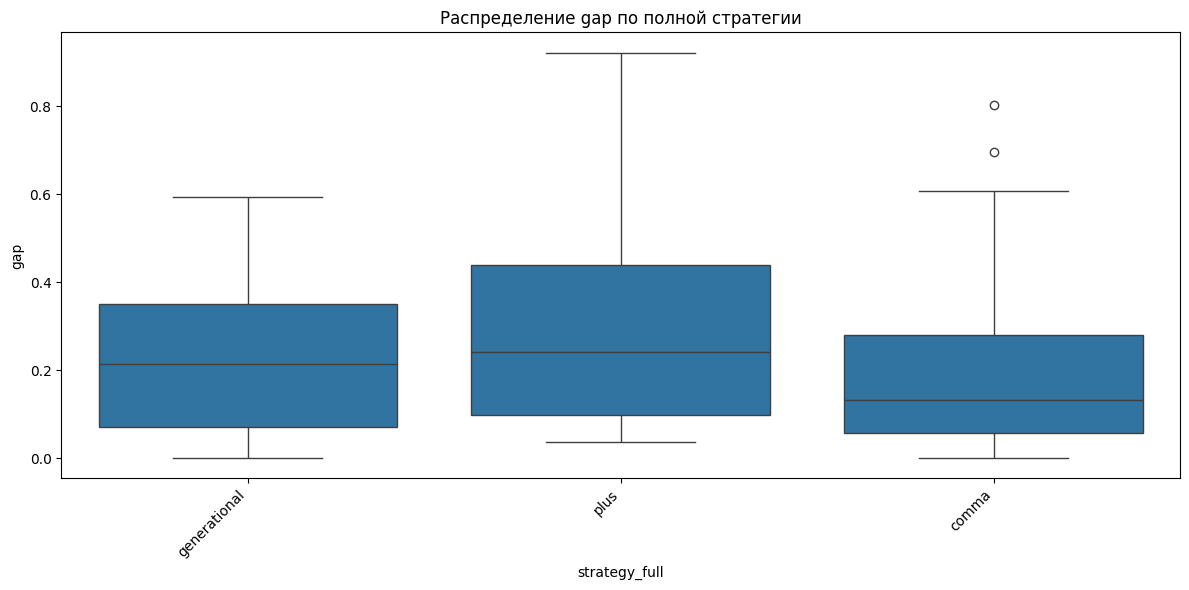

In [8]:
# ------------------------------------------------------------
# Детальный анализ: gap по стратегиям и методам ls
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='strategy_full', y='gap')
plt.title('Распределение gap по полной стратегии')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

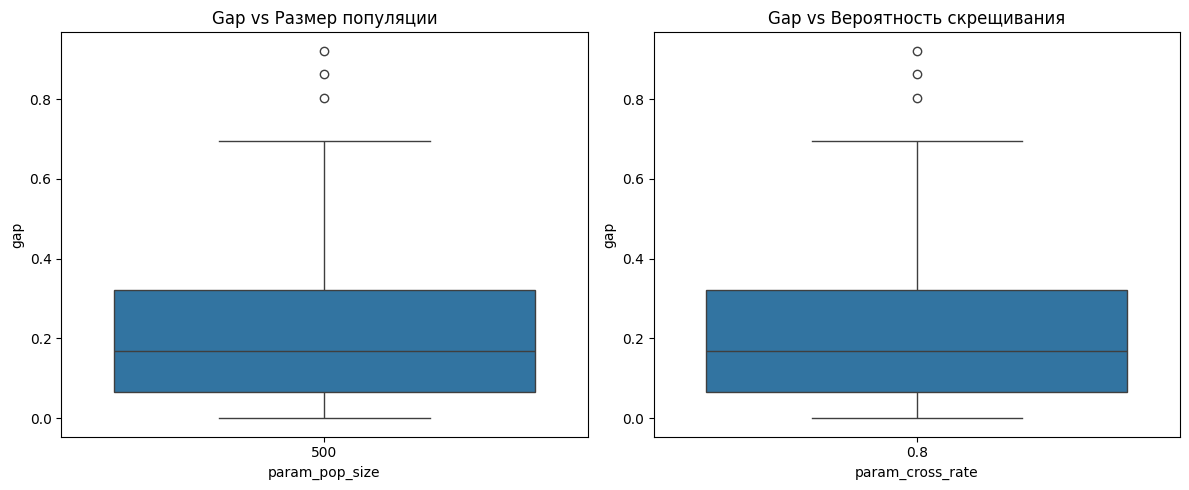

In [9]:
# ------------------------------------------------------------
# Влияние отдельных параметров (пример для pop_size, cross_rate)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='param_pop_size', y='gap', ax=axes[0])
axes[0].set_title('Gap vs Размер популяции')
sns.boxplot(data=df, x='param_cross_rate', y='gap', ax=axes[1])
axes[1].set_title('Gap vs Вероятность скрещивания')
plt.tight_layout()
plt.show()

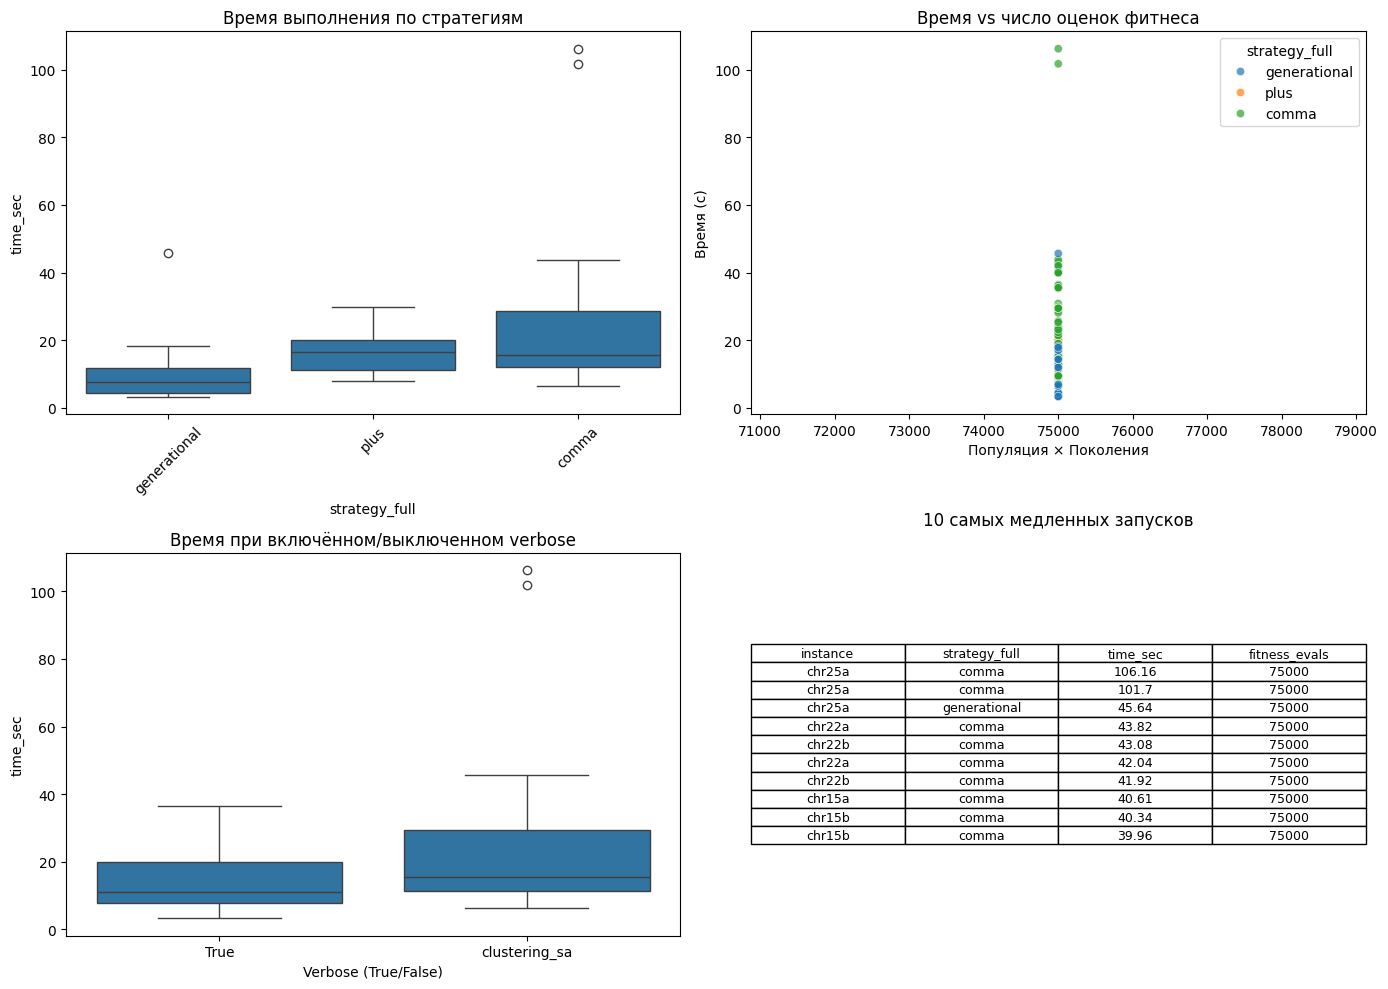

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1a. Распределение времени по стратегиям
sns.boxplot(data=df, x='strategy_full', y='time_sec', ax=axes[0,0])
axes[0,0].set_title('Время выполнения по стратегиям')
axes[0,0].tick_params(axis='x', rotation=45)

# 1b. Время vs число вычислений фитнеса
sns.scatterplot(data=df, x='fitness_evals', y='time_sec', hue='strategy_full', 
                alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('Время vs число оценок фитнеса')
axes[0,1].set_xlabel('Популяция × Поколения')
axes[0,1].set_ylabel('Время (с)')

# 1c. Влияние verbose на время
sns.boxplot(data=df, x='param_verbose', y='time_sec', ax=axes[1,0])
axes[1,0].set_title('Время при включённом/выключенном verbose')
axes[1,0].set_xlabel('Verbose (True/False)')

# 1d. Самые медленные запуски (Top-10)
top_slow = df.nlargest(10, 'time_sec')[['instance','strategy_full','time_sec','fitness_evals']]
axes[1,1].axis('off')
table = axes[1,1].table(cellText=top_slow.values,
                        colLabels=top_slow.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[1,1].set_title('10 самых медленных запусков', pad=20)

plt.tight_layout()
plt.show()

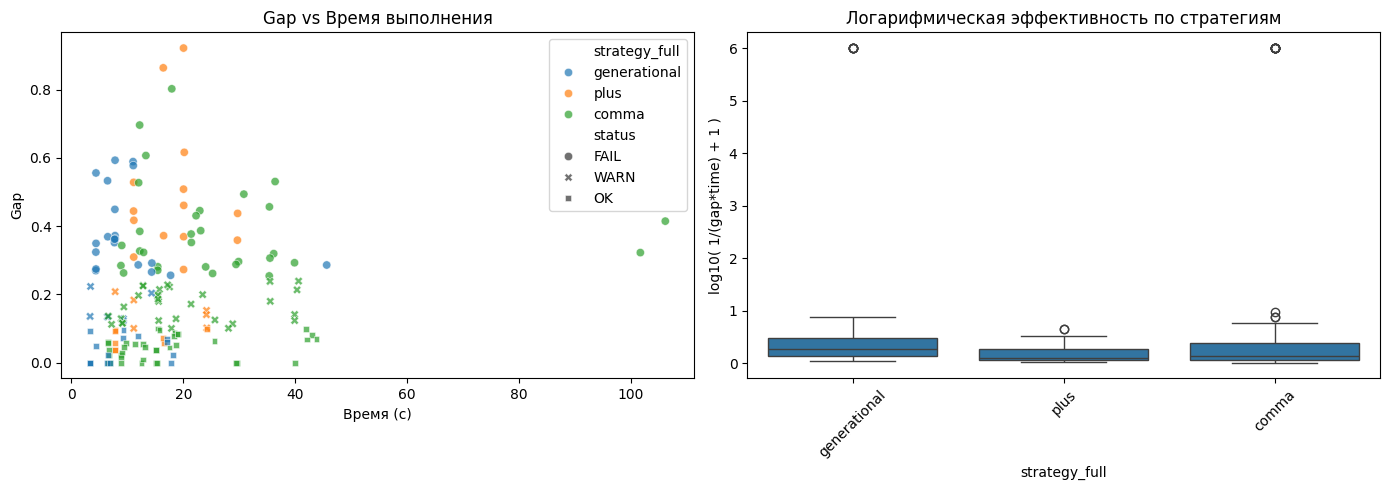

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2a. Gap vs время
sns.scatterplot(data=df, x='time_sec', y='gap', hue='strategy_full', 
                style='status', alpha=0.7, ax=axes[0])
axes[0].set_title('Gap vs Время выполнения')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Gap')

# 2b. Эффективность (чем выше, тем лучше)
sns.boxplot(data=df, x='strategy_full', y='log_efficiency', ax=axes[1])
axes[1].set_title('Логарифмическая эффективность по стратегиям')
axes[1].set_ylabel('log10( 1/(gap*time) + 1 )')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

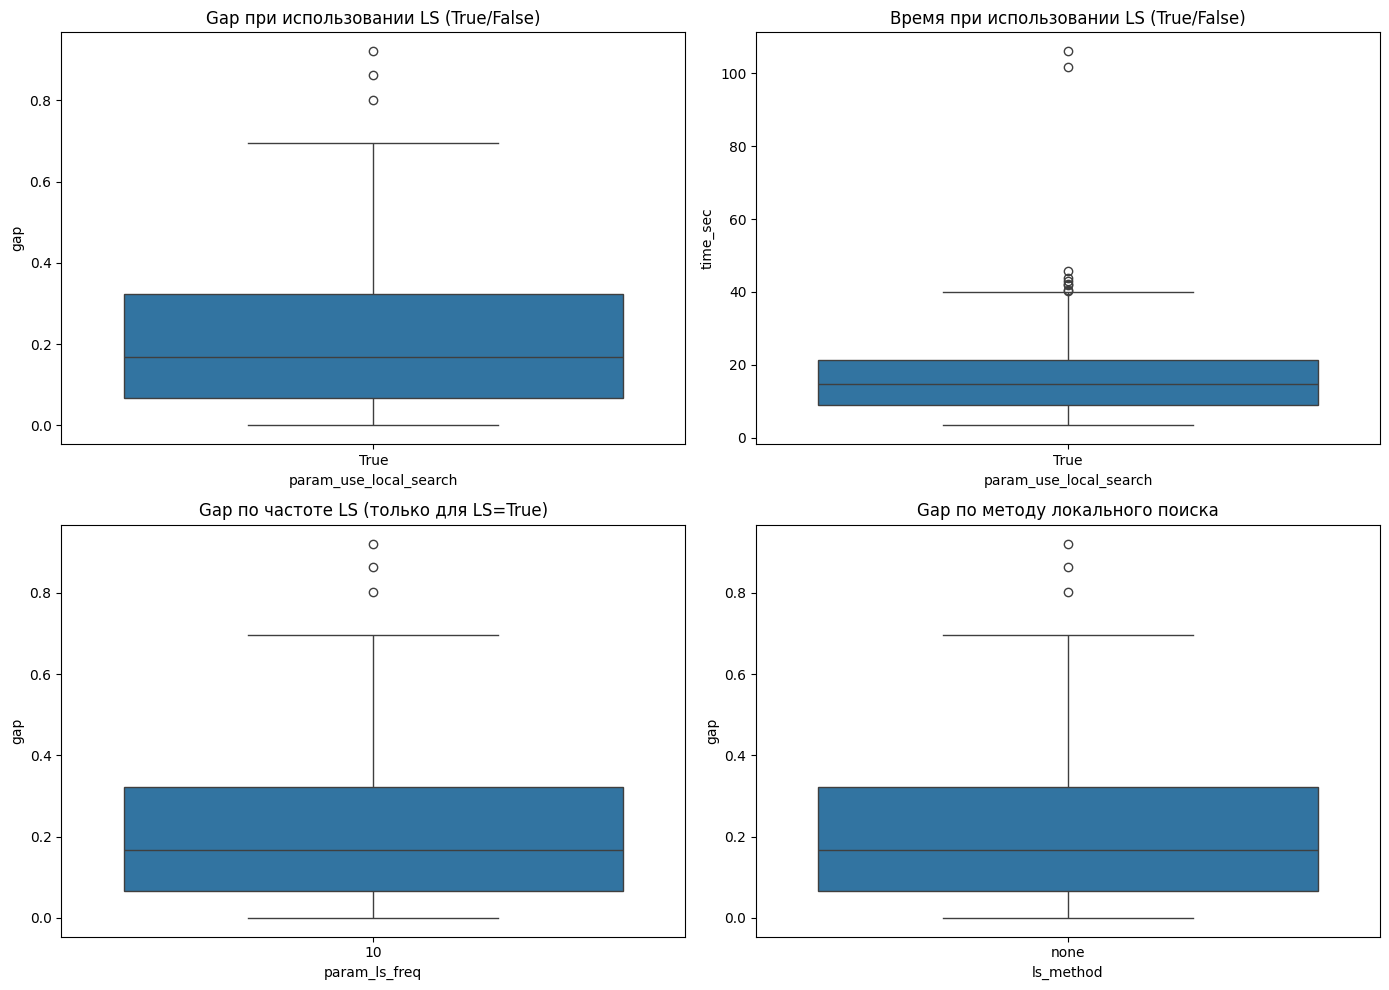

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a. Gap с LS и без
sns.boxplot(data=df, x='param_use_local_search', y='gap', ax=axes[0,0])
axes[0,0].set_title('Gap при использовании LS (True/False)')

# 3b. Время с LS и без
sns.boxplot(data=df, x='param_use_local_search', y='time_sec', ax=axes[0,1])
axes[0,1].set_title('Время при использовании LS (True/False)')

# 3c. Влияние частоты LS
sns.boxplot(data=df[df['param_use_local_search']==True], 
            x='param_ls_freq', y='gap', ax=axes[1,0])
axes[1,0].set_title('Gap по частоте LS (только для LS=True)')

# 3d. Сравнение методов LS (если есть clustering_sa vs none)
sns.boxplot(data=df, x='ls_method', y='gap', ax=axes[1,1])
axes[1,1].set_title('Gap по методу локального поиска')

plt.tight_layout()
plt.show()

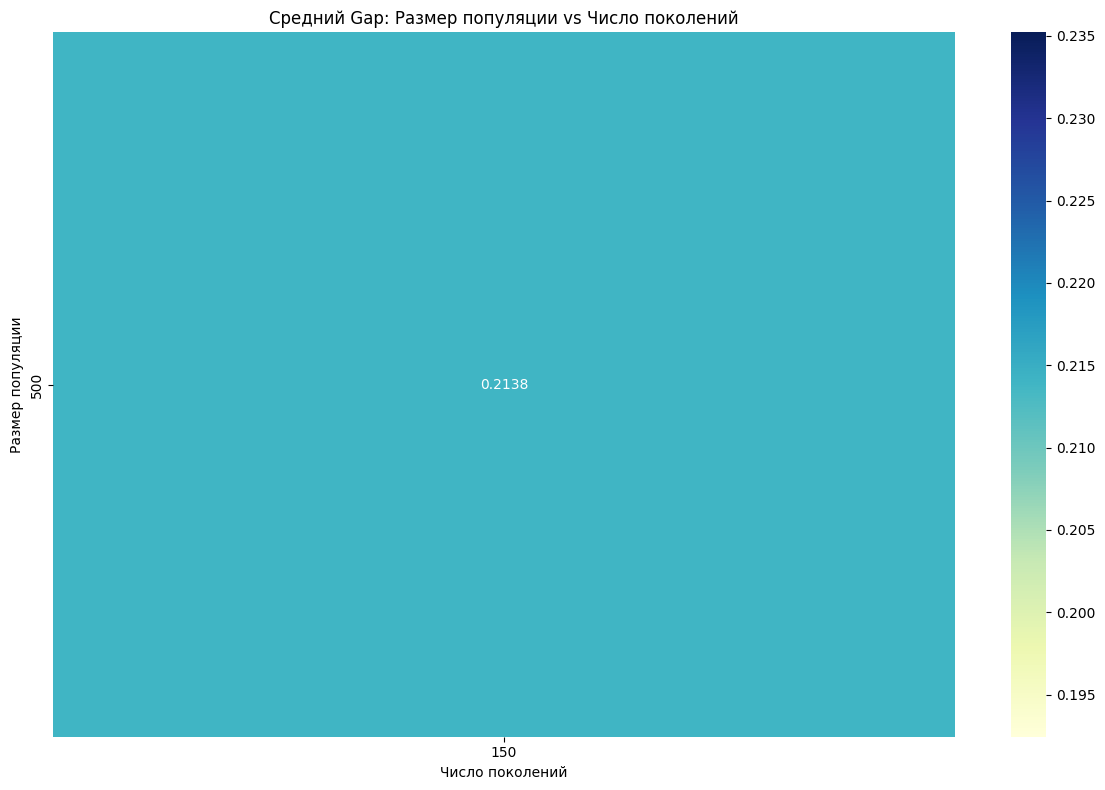

In [16]:
# Тепловая карта: средний gap по сетке pop_size × gens
pivot = df.pivot_table(values='gap', index='param_pop_size', 
                       columns='param_gens', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Средний Gap: Размер популяции vs Число поколений')
plt.xlabel('Число поколений')
plt.ylabel('Размер популяции')
plt.tight_layout()
plt.show()

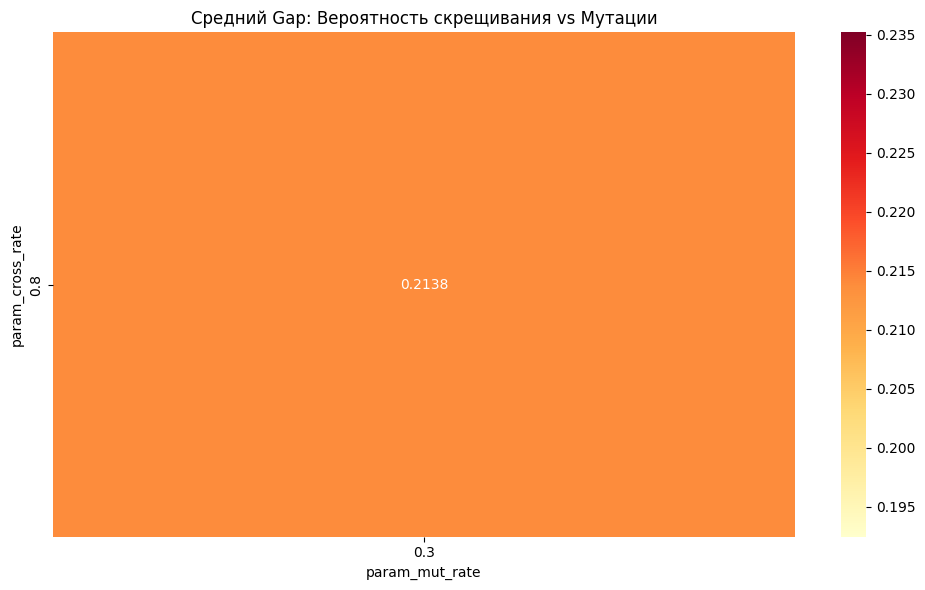

In [17]:
# Взаимодействие cross_rate и mut_rate
pivot2 = df.pivot_table(values='gap', index='param_cross_rate', 
                        columns='param_mut_rate', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot2, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Средний Gap: Вероятность скрещивания vs Мутации')
plt.tight_layout()
plt.show()

In [19]:
def categorize_gap(g):
    if g == 0:
        return 'Optimal'
    elif g < 0.01:
        return 'Excellent (<1%)'
    elif g < 0.05:
        return 'Good (<5%)'
    elif g < 0.1:
        return 'Fair (<10%)'
    else:
        return 'Poor (>=10%)'

df['gap_category'] = df['gap'].apply(categorize_gap)
cat_order = ['Optimal', 'Excellent (<1%)', 'Good (<5%)', 'Fair (<10%)', 'Poor (>=10%)']

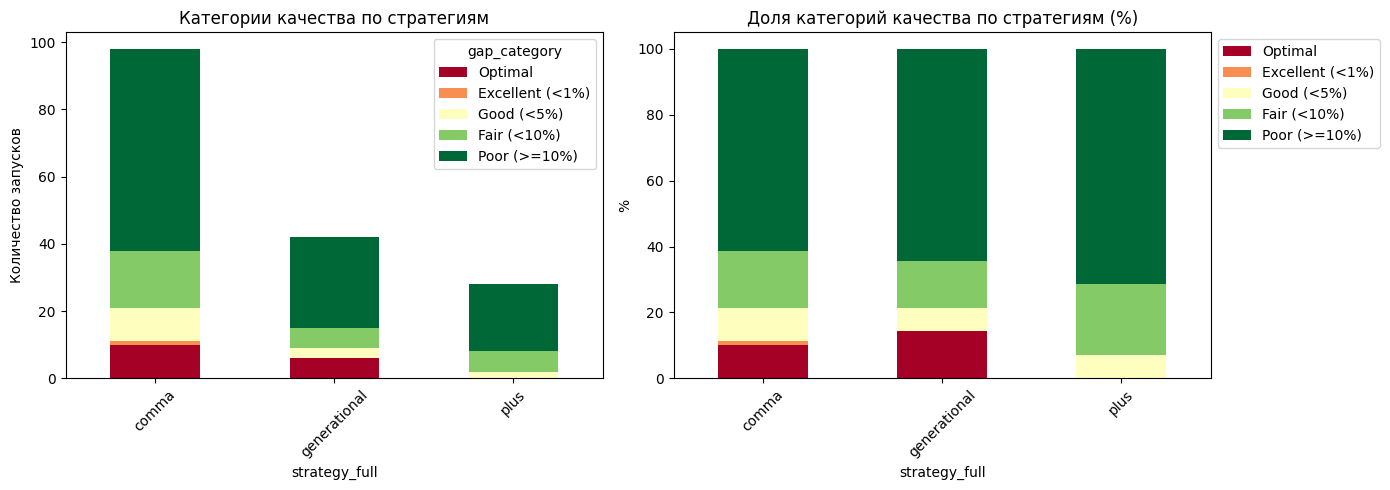

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_counts = df.groupby(['strategy_full', 'gap_category']).size().unstack().fillna(0)
cat_counts = cat_counts.reindex(columns=cat_order, fill_value=0)
cat_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Категории качества по стратегиям')
axes[0].set_ylabel('Количество запусков')
axes[0].tick_params(axis='x', rotation=45)

# Процентное соотношение
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100
cat_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Доля категорий качества по стратегиям (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()